# RAPIDS & Scanpy Single-Cell RNA-seq Workflow on mouse NAc cells

Copyright (c) 2020, NVIDIA CORPORATION.

Licensed under the Apache License, Version 2.0 (the "License") you may not use this file except in compliance with the License. You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

This notebook demonstrates a single-cell RNA analysis workflow that begins with preprocessing a count matrix of size `(n_gene, n_cell)` and results in a visualization of the clustered cells for further analysis.

For demonstration purposes, we use a dataset of 1.3 M brain cells with Unified Virtual Memory to oversubscribe GPU memory.

## Import requirements

In [1]:
import numpy as np
import scanpy as sc
import anndata
import scipy.io
import scipy.sparse

import time
import os, wget


import cudf

from cuml.decomposition import PCA
from cuml.manifold import TSNE
from cuml.cluster import KMeans
from cuml.preprocessing import StandardScaler

import cuml
import rapids_scanpy_funcs
import utils

import warnings
warnings.filterwarnings('ignore', 'Expected ')
warnings.simplefilter('ignore')
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import rmm

from rmm.allocators.cupy import rmm_cupy_allocator
import cupy
cupy.cuda.set_allocator(rmm_cupy_allocator)
from scipy import sparse
import gc
import cupy as cp
gc.collect()
cp.get_default_memory_pool().free_all_blocks()
import calculation_tool as ct

We use the RAPIDS memory manager to enable Unified Virtual Memory management, which allows us to oversubscribe the GPU memory.

## Input data

In the cell below, we provide the path to the sparse `.h5ad` file containing the count matrix to analyze. Please see the README for instructions on how to download the dataset we use here.

To run this notebook using your own dataset, please see the README for instructions to convert your own count matrix into this format. Then, replace the path in the cell below with the path to your generated `.h5ad` file.

## load data

In [ ]:
import os
import scanpy as sc
import pandas as pd
from scipy import sparse
import anndata

def load_and_merge_data_v3(base_dir):
    # 処理する条件（controlとschizophrenia）をリストとして定義
    conditions = ['control', 'schizophrenia']
    
    count = 0
    for condition in conditions:
        condition_path = os.path.join(base_dir, condition)
        
        # 各条件下でのサンプル名（MB7、MB8など）を取得
        samples = os.listdir(condition_path)
        
        for sample in samples:
            sample_path = os.path.join(condition_path, sample, 'matrix.tsv')
            
            # pandasでTSVファイルを読み込み
            if count == 0:
                adata=sc.read_csv(sample_path,delimiter='\t').T
                sparse_X = sparse.csr_matrix(adata.X)
                adata.X = sparse_X
                adata.obs['condition'] = condition
                adata.obs['sample'] = sample
            else:
                adata_append = sc.read_csv(sample_path,delimiter='\t').T
                sparse_X = sparse.csr_matrix(adata_append.X)
                adata_append.X = sparse_X
                adata_append.obs['condition'] = condition
                adata_append.obs['sample'] = sample
            
                # 連結
                adata = anndata.concat([adata, adata_append])
                print(adata.X.shape)
            
            count += 1
            
    return adata

base_dir = '/temp/data/human_Sz_PFC_each'
#adata = load_and_merge_data_v3(base_dir)
file_path="/temp/data/human_Sz_PFC_each/merged_adata.h5ad"
#adata.write(file_path)

In [4]:
file_path=r"/data/human_PFC/snRNA-seq_Human_annot.h5ad"
adata = anndata.read_h5ad(file_path)

OSError: Unable to synchronously open file (truncated file: eof = 2558623744, sblock->base_addr = 0, stored_eof = 3486994944)

In [3]:
import pandas as pd
df = pd.read_csv(file_path, sep="\t", index_col=0)

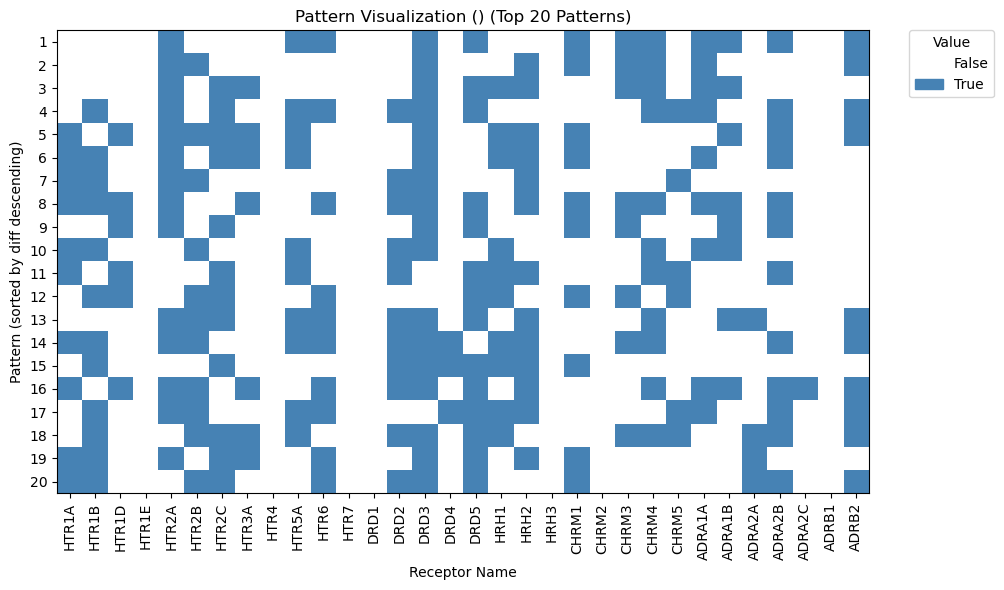

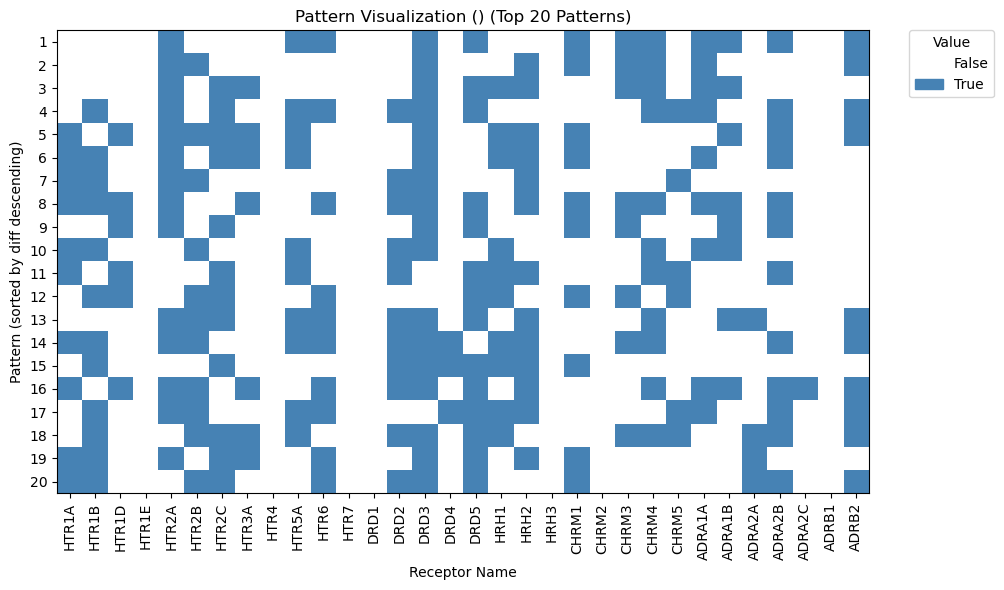

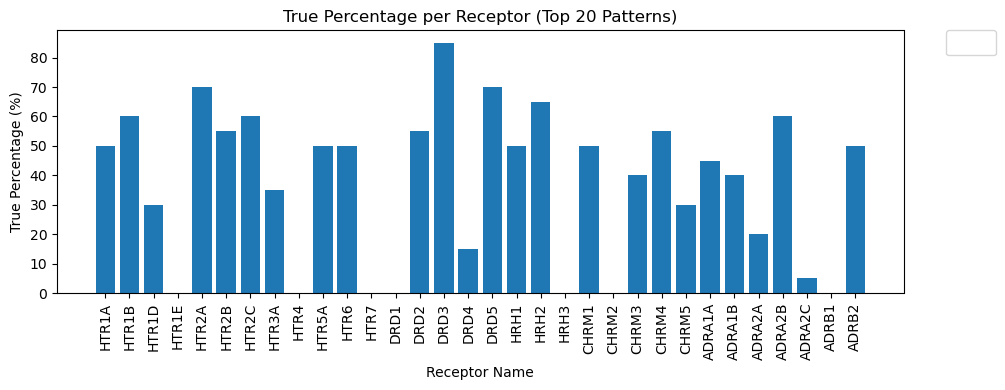

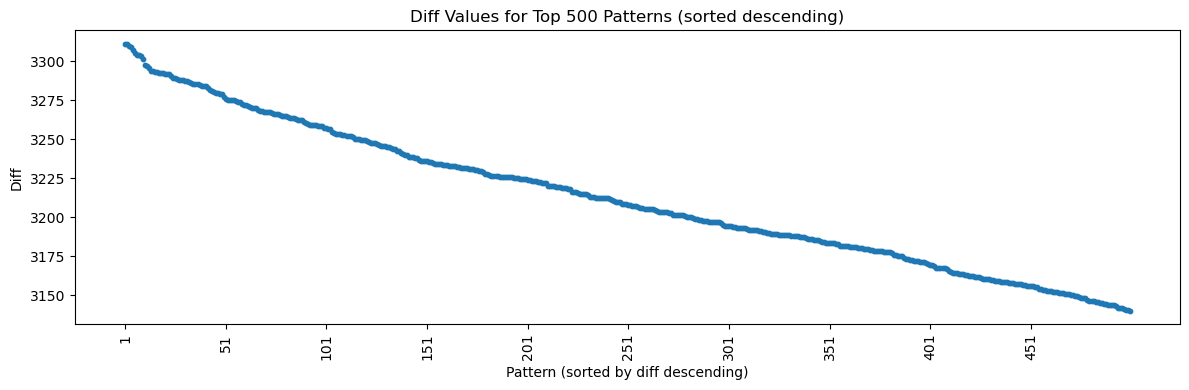

In [ ]:
ct.visualize_patterns(results_df_sorted, top_n=20, top_n_for_heatmap=20, scatter_n=500)

In [6]:
import anndata
adata = anndata.AnnData(X=df.T)

In [26]:
adata.X = adata.X.astype(np.float32)

In [27]:
adata_file_path="/data/human_frontal_cortex/GSE97930_adata.h5ad"
adata.write(adata_file_path)

In [25]:

# adata.X が scipy.sparse の sparse 行列の場合もまず NumPy の dense 行列に変換
if hasattr(adata.X, "toarray"):
    X_dense = adata.X.toarray()
else:
    X_dense = np.array(adata.X)

# 数値型（例：float32）にキャスト
X_dense = X_dense.astype(np.float32)

# NumPy の dense 行列を Cupy の dense 行列に変換
dense_gpu_array = cp.array(X_dense)

# Cupy の dense 配列から sparse (CSR) 行列に変換
sparse_gpu_array = cp.sparse.csr_matrix(dense_gpu_array)

preprocess_in_bulk
HTR1A is not included
HTR1A is removed from marker list
ADRA2B is not included
ADRA2B is removed from marker list
['CX3CR1', 'CLDN5', 'GLUL', 'NDRG2', 'PCDH15', 'PLP1', 'MBP', 'SATB2', 'SLC17A7', 'SLC17A6', 'GAD2', 'GAD1', 'SNAP25', 'HTR1B', 'HTR1D', 'HTR1E', 'HTR2A', 'HTR2B', 'HTR2C', 'HTR3A', 'HTR4', 'HTR5A', 'HTR6', 'HTR7', 'DRD1', 'DRD2', 'DRD3', 'DRD4', 'DRD5', 'HRH1', 'HRH2', 'HRH3', 'CHRM1', 'CHRM2', 'CHRM3', 'CHRM4', 'CHRM5', 'ADRA1A', 'ADRA1B', 'ADRA2A', 'ADRA2C', 'ADRB1', 'ADRB2']
perform regression
perform scale
float32
Total Preprocessing time: 5.514451503753662
shape of adata: (10319, 32472)
shape of adata: (10319, 32472)
perform PCA
10
t-sne
UMAP
[2025-04-10 07:30:10.074] [CUML] [info] build_algo set to brute_force_knn because random_state is given
UMAP louvain


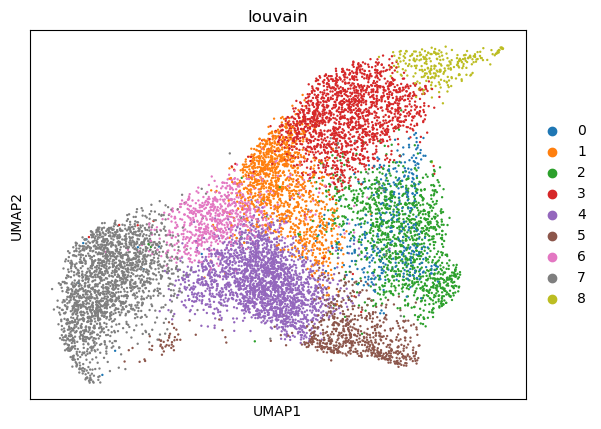

UMAP leiden


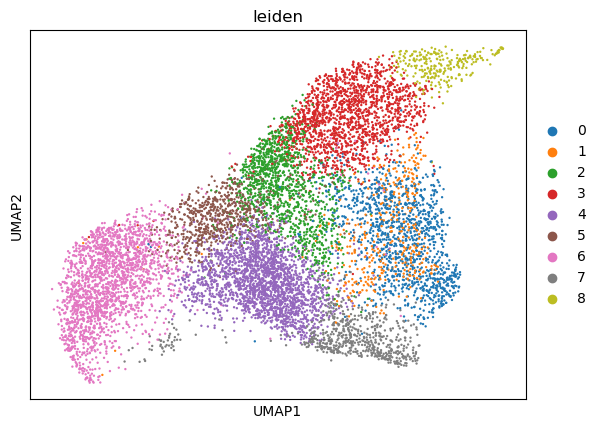

calc drug response
clz selective cells
# of clz selective cells: is_clz_selective
False    9785
True      534
Name: count, dtype: int64


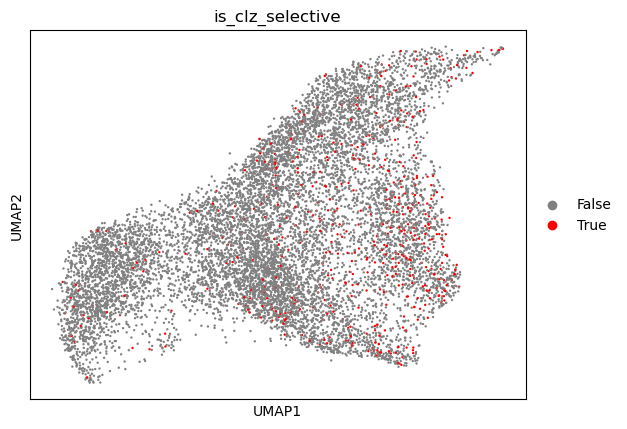

In [28]:
file_path="/data/human_frontal_cortex/GSE97930_adata.h5ad"
adata,GPCR_df=ct.preprocess_adata_in_bulk(file_path,label=None,is_gpu=False)
GPCR_df.to_csv("/data/human_frontal_cortex/combined_data_GPCR_df.csv")

Drug concentration: 0.001
clz selective cells
# of clz selective cells: is_clz_selective
False    10229
True        90
Name: count, dtype: int64


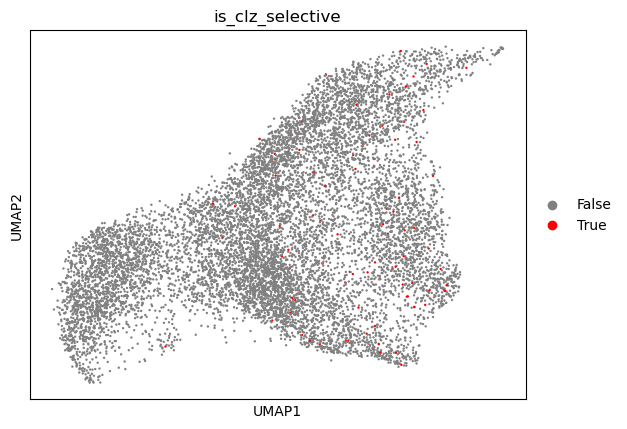

Drug concentration: 0.01
clz selective cells
# of clz selective cells: is_clz_selective
False    10229
True        90
Name: count, dtype: int64


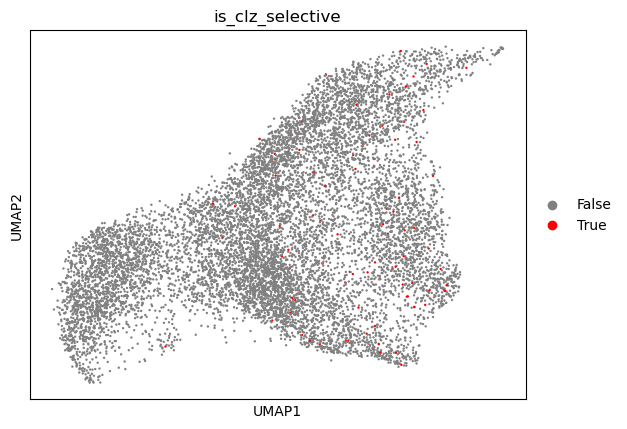

Drug concentration: 0.1
clz selective cells
# of clz selective cells: is_clz_selective
False    10229
True        90
Name: count, dtype: int64


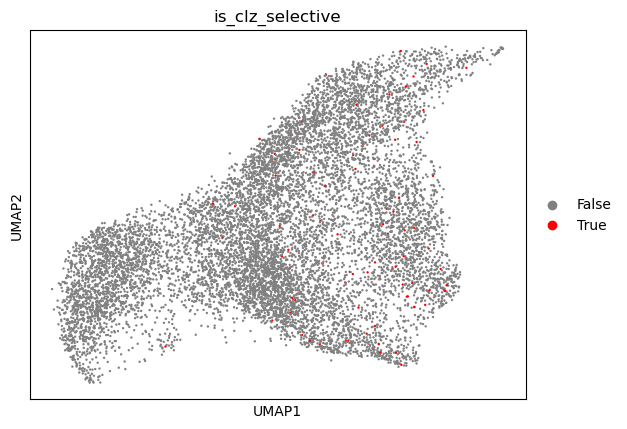

Drug concentration: 1
clz selective cells
# of clz selective cells: is_clz_selective
False    10227
True        92
Name: count, dtype: int64


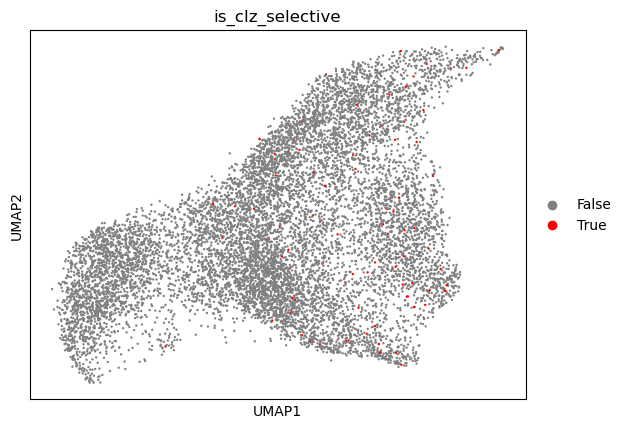

Drug concentration: 1.5848931924611136
clz selective cells
# of clz selective cells: is_clz_selective
False    10225
True        94
Name: count, dtype: int64


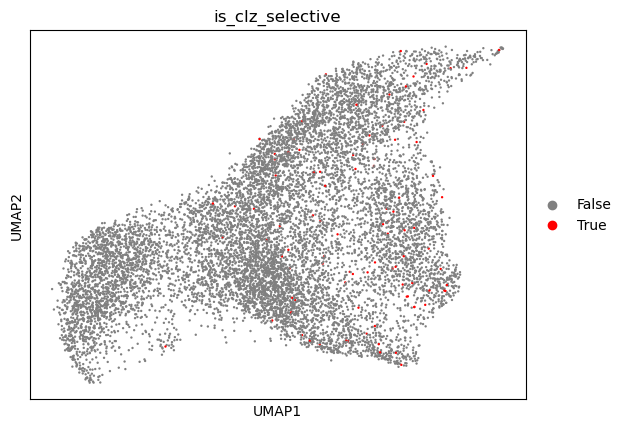

Drug concentration: 2.2387211385683394
clz selective cells
# of clz selective cells: is_clz_selective
False    10224
True        95
Name: count, dtype: int64


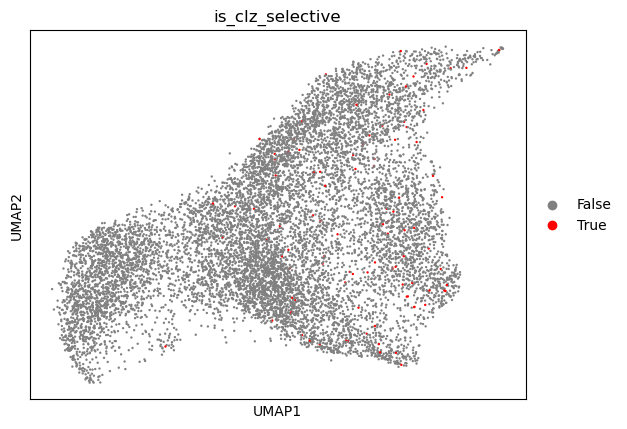

Drug concentration: 3.1622776601683795
clz selective cells
# of clz selective cells: is_clz_selective
False    10166
True       153
Name: count, dtype: int64


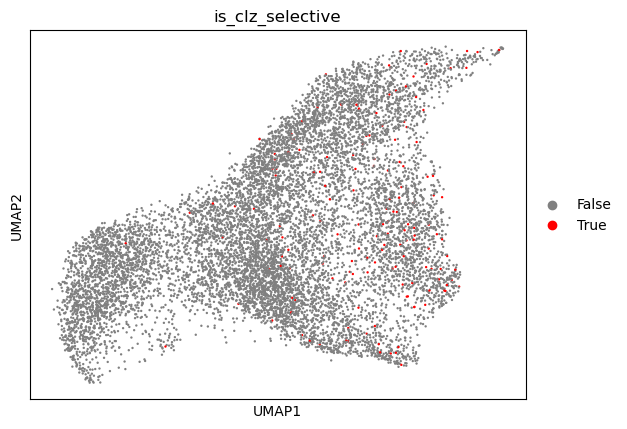

Drug concentration: 5.623413251903491
clz selective cells
# of clz selective cells: is_clz_selective
False    10164
True       155
Name: count, dtype: int64


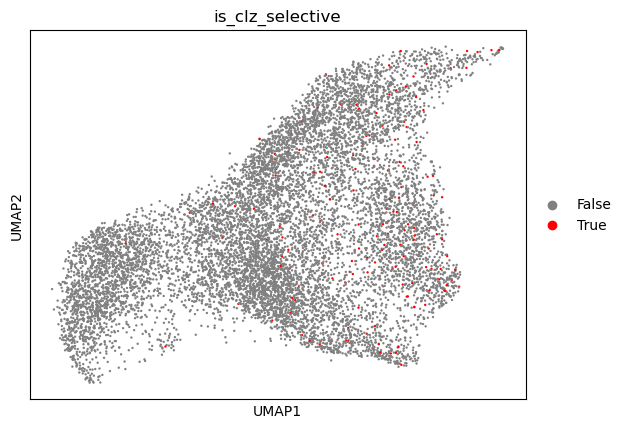

Drug concentration: 10
clz selective cells
# of clz selective cells: is_clz_selective
False    10145
True       174
Name: count, dtype: int64


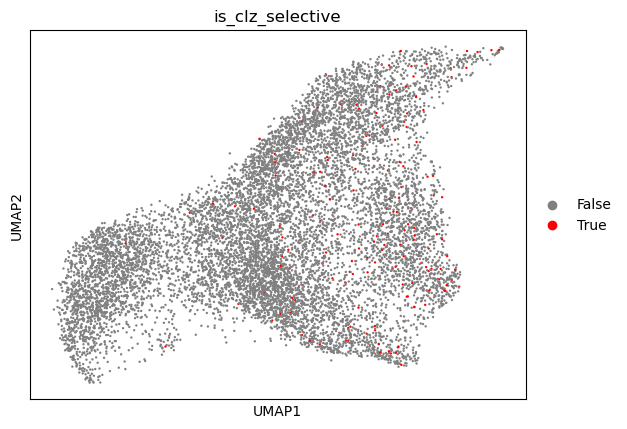

Drug concentration: 31.622776601683793
clz selective cells
# of clz selective cells: is_clz_selective
False    10116
True       203
Name: count, dtype: int64


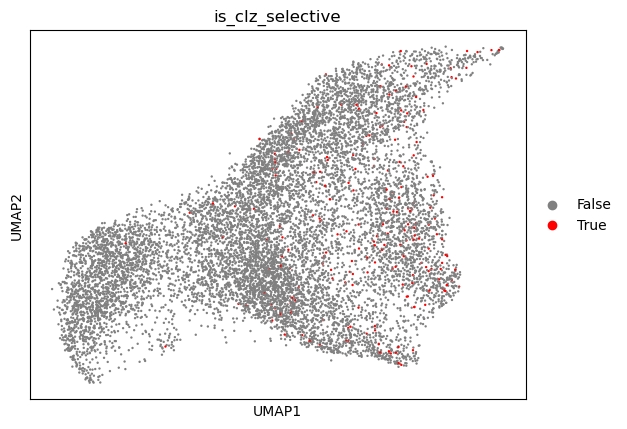

Drug concentration: 100
clz selective cells
# of clz selective cells: is_clz_selective
False    9808
True      511
Name: count, dtype: int64


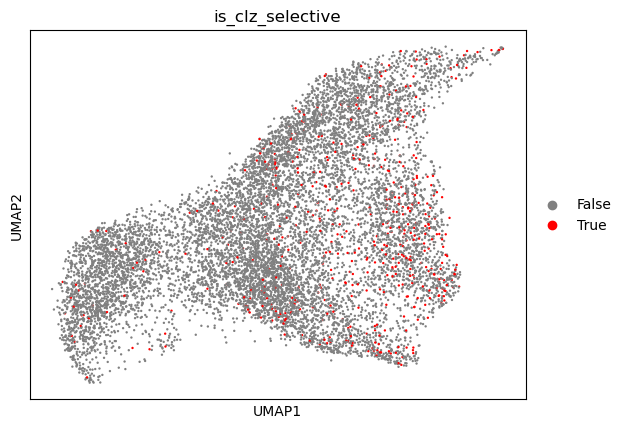

Drug concentration: 316.22776601683796
clz selective cells
# of clz selective cells: is_clz_selective
False    9791
True      528
Name: count, dtype: int64


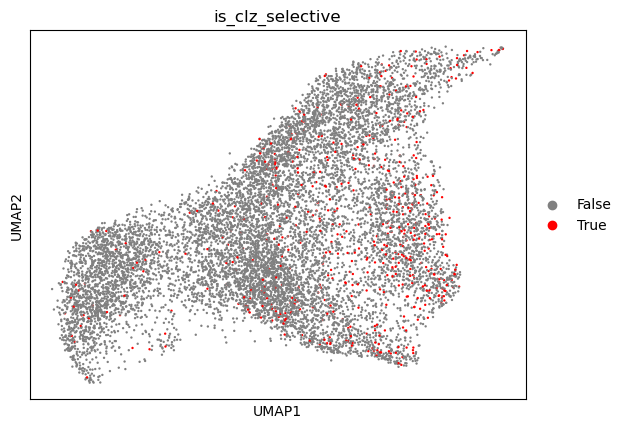

Drug concentration: 1000
clz selective cells
# of clz selective cells: is_clz_selective
False    9746
True      573
Name: count, dtype: int64


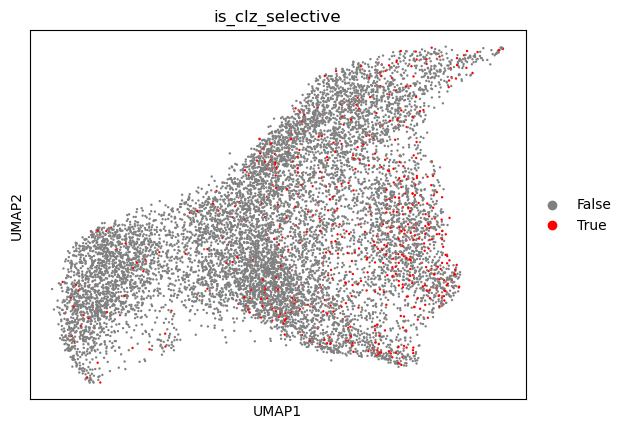

Drug concentration: 10000
clz selective cells
# of clz selective cells: is_clz_selective
False    9835
True      484
Name: count, dtype: int64


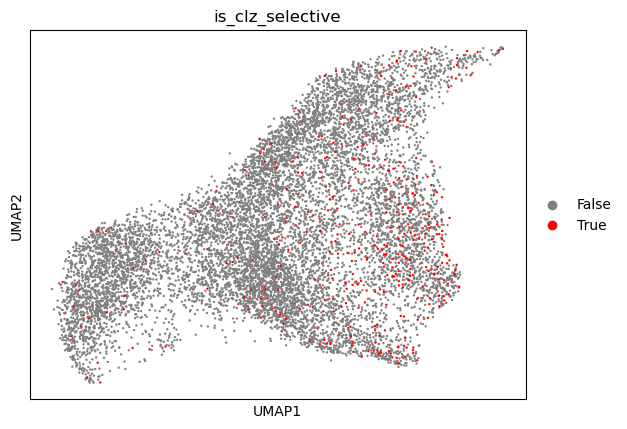

Drug concentration: 100000
clz selective cells
# of clz selective cells: is_clz_selective
False    9931
True      388
Name: count, dtype: int64


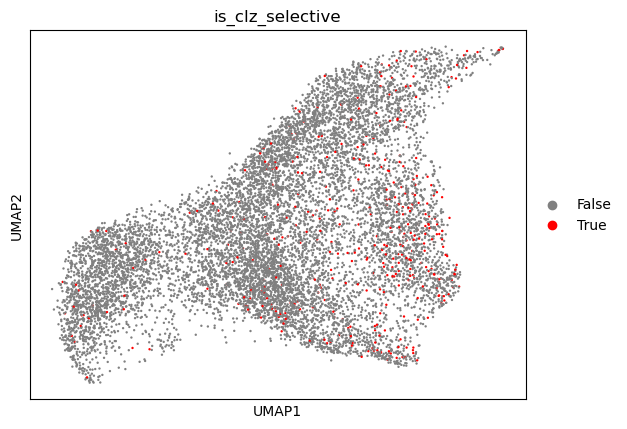

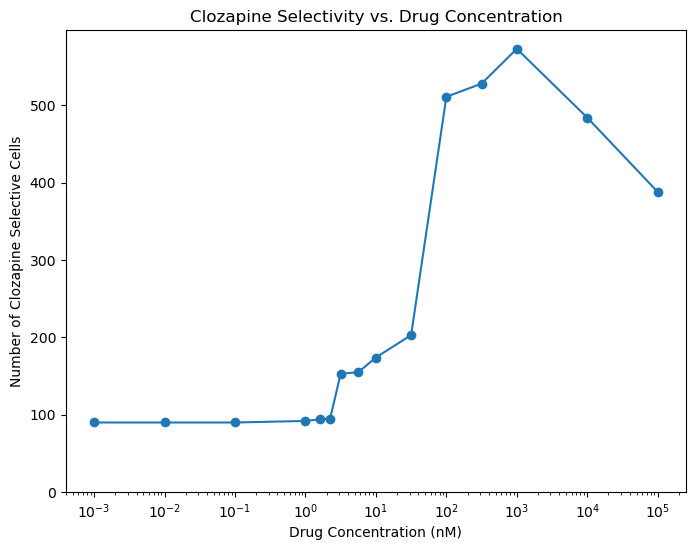

In [29]:
D_R_mtx,GPCR_type_df,drug_list,GPCR_list=ct.load_parameters()
params=ct.set_parameters_for_preprocess(GPCR_list)
import calculation_tool as ct
ct.drug_titeration(adata, GPCR_df, GPCR_type_df, drug_list, D_R_mtx)

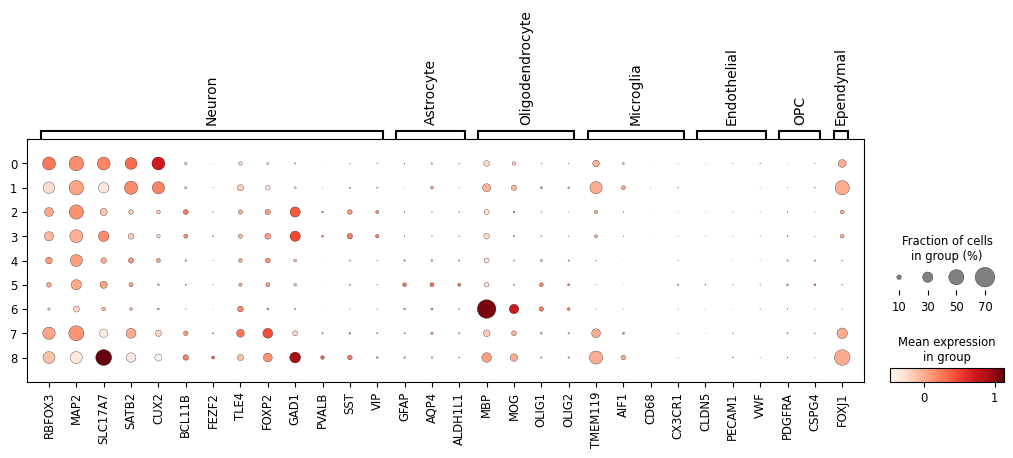

In [30]:
marker_genes_dict = {
    "Neuron": ["RBFOX3", "MAP2", "SLC17A7", "SATB2", "CUX2","BCL11B", "FEZF2","TLE4", "FOXP2","GAD1","PVALB","SST","VIP"],
    "Astrocyte": ["GFAP", "AQP4", "ALDH1L1"],
    "Oligodendrocyte": ["MBP", "MOG", "OLIG1", "OLIG2"],
    "Microglia": ["TMEM119", "AIF1", "CD68", "CX3CR1"],
    "Endothelial": ["CLDN5", "PECAM1", "VWF"],
    "OPC": ["PDGFRA", "CSPG4"],
    "Ependymal": ["FOXJ1"]
}
sc.pl.dotplot(adata, marker_genes_dict, "leiden")

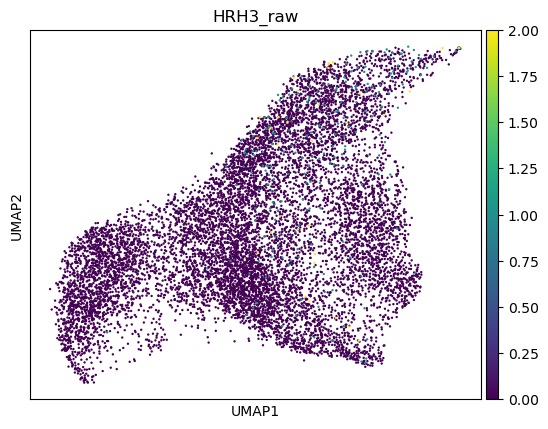

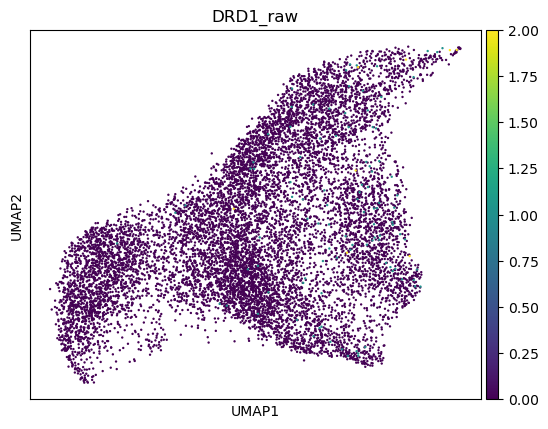

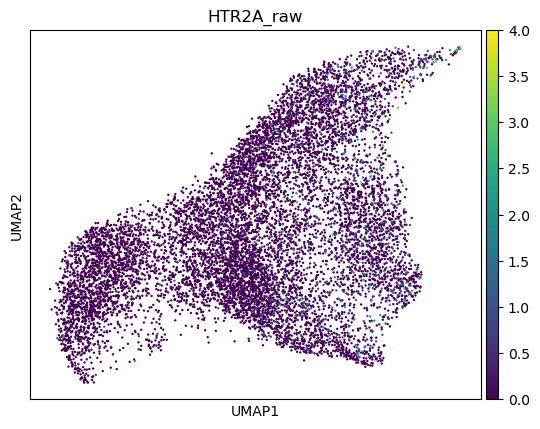

In [31]:
sc.pl.umap(adata, color=["HRH3_raw"])
sc.pl.umap(adata, color=["DRD1_raw"])
sc.pl.umap(adata, color=["HTR2A_raw"])

In [33]:
GPCR_adata=anndata.AnnData(X=GPCR_df)
GPCR_adata_norm=sc.pp.normalize_total(GPCR_adata,target_sum=1e4,inplace=False)['X']
GPCR_adata_norm_df=pd.DataFrame(GPCR_adata_norm,columns=GPCR_adata.var.index)

In [34]:
#import calculation_tool as ct

drug_conc=10**3
results_df_sorted,all_responses=ct.sim_inhibit_pattern(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc,n_pattern=10000)

Pattern_1: {'HTR1B_raw': True, 'HTR1D_raw': True, 'HTR1E_raw': False, 'HTR2A_raw': False, 'HTR2B_raw': True, 'HTR2C_raw': True, 'HTR3A_raw': False, 'HTR4_raw': True, 'HTR5A_raw': False, 'HTR6_raw': True, 'HTR7_raw': True, 'DRD1_raw': True, 'DRD2_raw': True, 'DRD3_raw': True, 'DRD4_raw': False, 'DRD5_raw': True, 'HRH1_raw': True, 'HRH2_raw': True, 'HRH3_raw': True, 'CHRM1_raw': True, 'CHRM2_raw': True, 'CHRM3_raw': False, 'CHRM4_raw': True, 'CHRM5_raw': False, 'ADRA1A_raw': True, 'ADRA1B_raw': False, 'ADRA2A_raw': True, 'ADRA2C_raw': False, 'ADRB1_raw': False, 'ADRB2_raw': False}
Pattern_2: {'HTR1B_raw': False, 'HTR1D_raw': False, 'HTR1E_raw': True, 'HTR2A_raw': True, 'HTR2B_raw': False, 'HTR2C_raw': True, 'HTR3A_raw': True, 'HTR4_raw': True, 'HTR5A_raw': True, 'HTR6_raw': True, 'HTR7_raw': True, 'DRD1_raw': True, 'DRD2_raw': True, 'DRD3_raw': True, 'DRD4_raw': False, 'DRD5_raw': False, 'HRH1_raw': False, 'HRH2_raw': True, 'HRH3_raw': True, 'CHRM1_raw': True, 'CHRM2_raw': False, 'CHRM3_

Simulating drug responses: 100%|██████████| 10000/10000 [01:30<00:00, 110.48it/s]

      pattern_name                                            pattern  \
2053  Pattern_2054  {'HTR1B_raw': True, 'HTR1D_raw': True, 'HTR1E_...   
5912  Pattern_5913  {'HTR1B_raw': True, 'HTR1D_raw': False, 'HTR1E...   
9011  Pattern_9012  {'HTR1B_raw': False, 'HTR1D_raw': True, 'HTR1E...   
658    Pattern_659  {'HTR1B_raw': False, 'HTR1D_raw': True, 'HTR1E...   
9121  Pattern_9122  {'HTR1B_raw': False, 'HTR1D_raw': True, 'HTR1E...   

             diff  
2053  4888.359638  
5912  4886.758224  
9011  4886.299994  
658   4885.201518  
9121  4884.576072  


In [35]:
dir="/data/human_frontal_cortex"
results_df_sorted.to_csv(os.path.join(dir,"results_df_sorted.csv"))
all_responses.to_csv(os.path.join(dir,"all_responses.csv"))

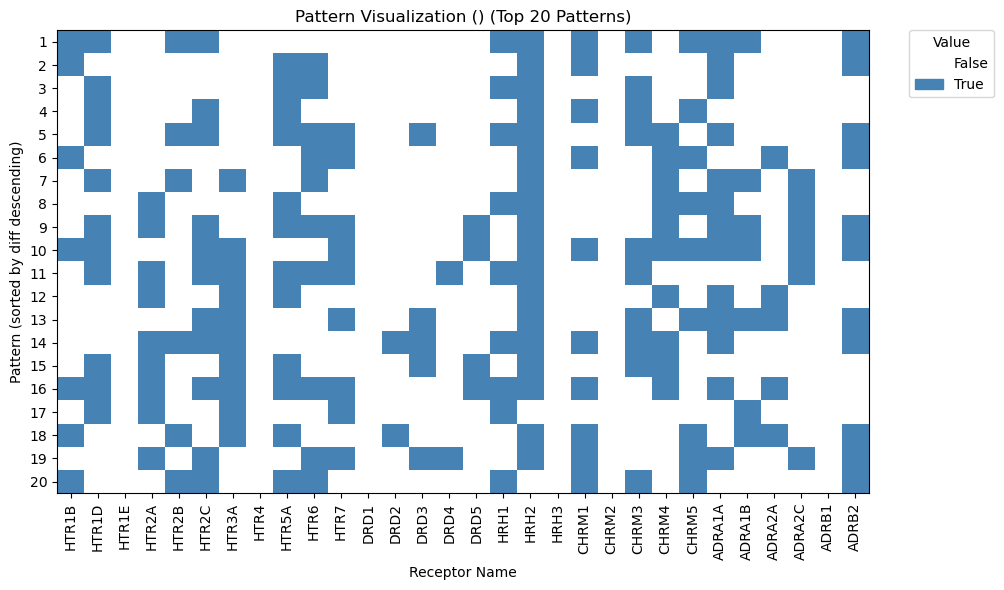

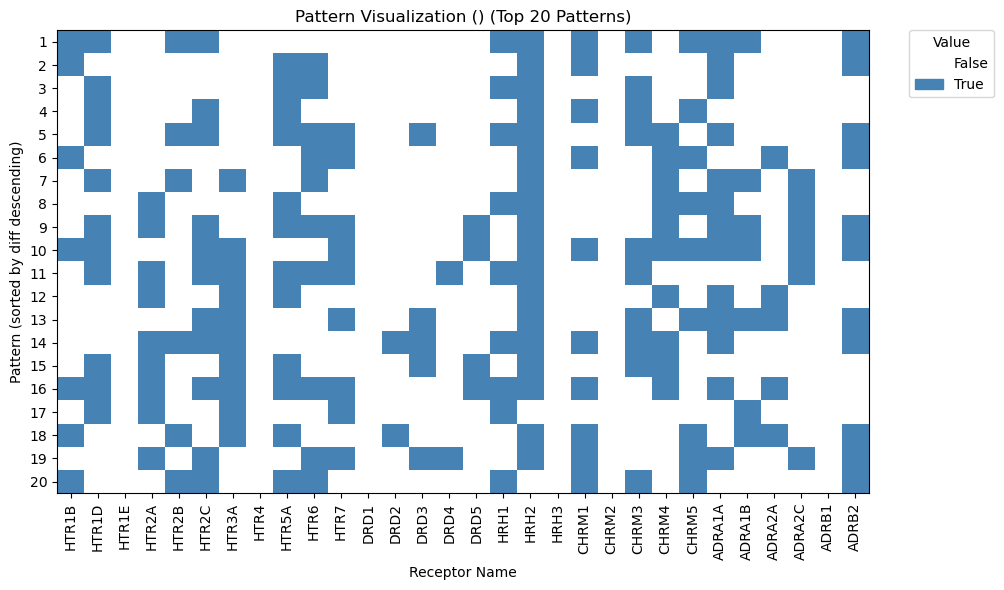

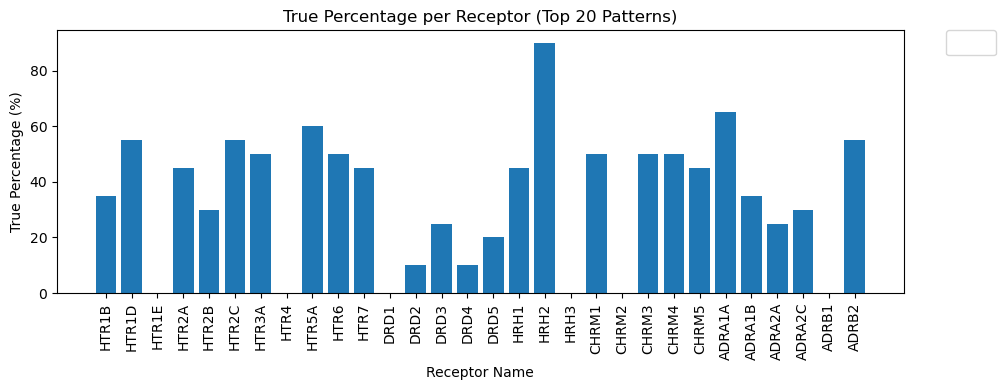

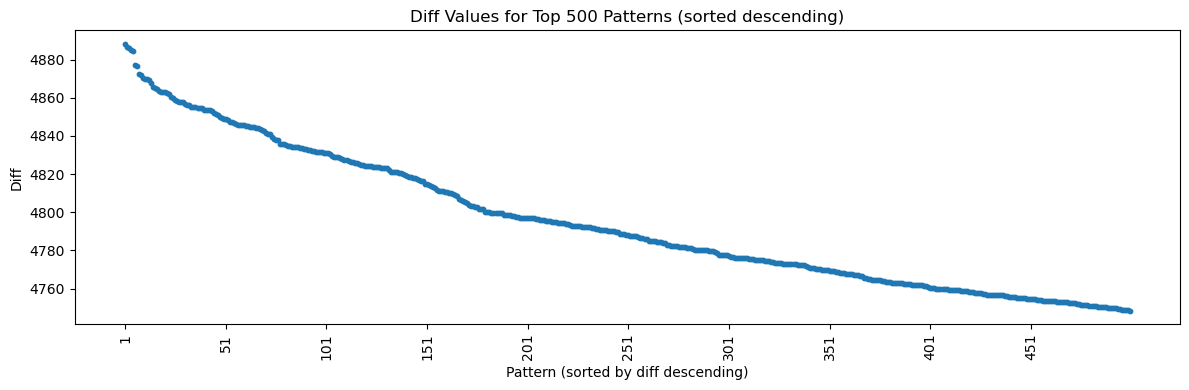

In [36]:
ct.visualize_patterns(results_df_sorted, top_n=20, top_n_for_heatmap=20, scatter_n=500)